In [18]:
import torch

torch.cuda.is_available()

True

In [20]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(torch.cuda.device_count())

NVIDIA GeForce RTX 5090
1


In [4]:
import torch
from dataset import get_data_transforms, load_data
from torchvision.datasets import ImageFolder
import numpy as np
from torch.utils.data import DataLoader
from resnet import resnet18, resnet34, resnet50, wide_resnet50_2
from de_resnet import de_resnet18, de_resnet50, de_wide_resnet50_2
from dataset import RD_Dataset
from torch.nn import functional as F
from sklearn.metrics import roc_auc_score
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from skimage import measure
import pandas as pd
from numpy import ndarray
from statistics import mean
from scipy.ndimage import gaussian_filter
from sklearn import manifold
from matplotlib.ticker import NullFormatter
from scipy.spatial.distance import pdist
import matplotlib
import pickle
import os

In [5]:
# Teacher와 Student의 Feature map을 받아와 Anomaly map을 생성하는 함수
def cal_anomaly_map(fs_list, ft_list, out_size=224, amap_mode='mul'):
    if amap_mode == 'mul':
        anomaly_map = np.ones([out_size, out_size])
    else:
        anomaly_map = np.zeros([out_size, out_size])
    a_map_list = []
    for i in range(len(ft_list)):
        fs = fs_list[i]
        ft = ft_list[i]
        #fs_norm = F.normalize(fs, p=2)
        #ft_norm = F.normalize(ft, p=2)
        a_map = 1 - F.cosine_similarity(fs, ft)
        a_map = torch.unsqueeze(a_map, dim=1)
        a_map = F.interpolate(a_map, size=out_size, mode='bilinear', align_corners=True)
        a_map = a_map[0, 0, :, :].to('cpu').detach().numpy()
        a_map_list.append(a_map)
        if amap_mode == 'mul':
            anomaly_map *= a_map
        else:
            anomaly_map += a_map
    return anomaly_map, a_map_list

In [6]:
# CAM을 생성해 보여주는 함수
def show_cam_on_image(img, anomaly_map):
    #if anomaly_map.shape != img.shape:
    #    anomaly_map = cv2.applyColorMap(np.uint8(anomaly_map), cv2.COLORMAP_JET)
    cam = np.float32(anomaly_map)/255 + np.float32(img)/255
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

In [7]:
# 최소값, 최댓값을 사용해 Normalize 해주는 함수
def min_max_norm(image):
    a_min, a_max = image.min(), image.max()
    return (image-a_min)/(a_max - a_min)

In [8]:
# 히트맵을 생성하는 함수
def cvt2heatmap(gray):
    heatmap = cv2.applyColorMap(np.uint8(gray), cv2.COLORMAP_JET)
    return heatmap

In [9]:
def createDirectory(directory):
    try:
        if not os.path.exists(directory):
            os.makedirs(directory)
    except OSError:
        print("Error: Failed to create the directory.")

In [10]:
# 불량영역을 시각화 해주는 함수
def visualization(_class_, PATH = 0):
    print(_class_)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(device)

    data_transform = get_data_transforms(256, 256)
    test_path = './data/' + _class_
    ckp_path = './checkpoints/' + 'wres50_'+_class_+'.pth'

    test_data = RD_Dataset(root=test_path, transform=data_transform, phase="test")
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False)
    print(test_dataloader)


    encoder, bn = wide_resnet50_2(pretrained=True)
    encoder = encoder.to(device)
    bn = bn.to(device)

    encoder.eval()
    decoder = de_wide_resnet50_2(pretrained=False)
    decoder = decoder.to(device)
    ckp = torch.load(ckp_path)
    for k, v in list(ckp['bn'].items()):
        if 'memory' in k:
            ckp['bn'].pop(k)
    decoder.load_state_dict(ckp['decoder'])
    bn.load_state_dict(ckp['bn'])

    count = 0
    with torch.no_grad():
        for img, label, _ in test_dataloader:
            # 정상 데이터의 시각화도 보고싶은 경우 continue를 삭제
            if (label.item() == 0):
                continue
                
            decoder.eval()
            bn.eval()

            img = img.to(device)
            inputs = encoder(img)
            outputs = decoder(bn(inputs))

            anomaly_map, amap_list = cal_anomaly_map([inputs[-1]], [outputs[-1]], img.shape[-1], amap_mode='a')
            anomaly_map = gaussian_filter(anomaly_map, sigma=4)
            #ano_map = min_max_norm(anomaly_map)
            ano_map = 1.0 - min_max_norm(anomaly_map)
            ano_map = cvt2heatmap(ano_map*255)
            img = cv2.cvtColor(img.permute(0, 2, 3, 1).cpu().numpy()[0] * 255, cv2.COLOR_BGR2RGB)
            img = np.uint8(min_max_norm(img)*255)

            ano_map = show_cam_on_image(img, ano_map)
            
            plt.imshow(ano_map)
            print("PATH : ", PATH)
            
            createDirectory(PATH)
            
            if PATH != 0:
                plt.savefig(PATH + 'ad_' + _[0] + str(count) +'.png')
            plt.axis('off')
            plt.show()


            count += 1

In [11]:
# 불량점수를 계산하는 함수
def anomaly_score_calculator(_class_):
    print(_class_)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(device)

    data_transform = get_data_transforms(256, 256)
    test_path = './data/' + _class_
    ckp_path = './checkpoints/' + 'wres50_'+_class_+'.pth'
    
    test_data = RD_Dataset(root=test_path, transform=data_transform, phase="test")
    test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False)

    encoder, bn = wide_resnet50_2(pretrained=True)
    encoder = encoder.to(device)
    bn = bn.to(device)

    encoder.eval()
    decoder = de_wide_resnet50_2(pretrained=False)
    decoder = decoder.to(device)
    ckp = torch.load(ckp_path)
    for k, v in list(ckp['bn'].items()):
        if 'memory' in k:
            ckp['bn'].pop(k)
    decoder.load_state_dict(ckp['decoder'])
    bn.load_state_dict(ckp['bn'])
    
    bn.eval()
    decoder.eval()
    
    
    pr_list_px = []
    pr_list_sp = []
    aupro_list = []
    img_labels = []
    
    
    with torch.no_grad():
        for img, label, _ in test_dataloader:
            
            #print("_", _[0])
            img_labels.append(_[0])

            img = img.to(device)
            inputs = encoder(img)
            outputs = decoder(bn(inputs))
            anomaly_map, _ = cal_anomaly_map(inputs, outputs, img.shape[-1], amap_mode='a')
            anomaly_map = gaussian_filter(anomaly_map, sigma=4)

            pr_list_px.extend(anomaly_map.ravel())
            pr_list_sp.append(np.max(anomaly_map))

        ano_score = (pr_list_sp - np.min(pr_list_sp)) / (np.max(pr_list_sp) - np.min(pr_list_sp))
    
    return img_labels, ano_score

In [12]:
# class와 threshold를 받아 Classification을 수행
def classification_with_threshold(_class_, threshold):
    torch.cuda.empty_cache()

    target_label = _class_
    img_labels, ano_score = anomaly_score_calculator(target_label)   
    
    threshold = threshold
    new_table = []

    length = len(ano_score)
    TP = 0
    FN = 0
    FP = 0
    TN = 0

    for j in range(length):
        if img_labels[j] == 'good':
            if ano_score[j] < threshold:
                TN += 1
            else:
                FP += 1
        else:
            if ano_score[j] < threshold:
                FN += 1
            else:
                TP += 1

    Accuracy = (TN + TP)/(TN + TP + FN + FP)
    Precision = (TP)/(TP + FP)
    Recall = (TP)/(TP + FN)
    Fall_out = FP/(TN + FP)
    
    if (Precision != 0)&(Recall != 0):
        F1_score = 2*(Precision*Recall)/(Precision + Recall)
    else:
        F1_score = 0
      
    print('threshold : ', threshold)
    print('TP : ', TP)
    print('FN : ', FN)
    print('FP : ', FP)
    print('TN : ', TN)
    print('Accuracy : ', Accuracy)
    print('Precision : ', Precision)
    print('Recall : ', Recall)
    print('Fall_out :', Fall_out)

In [13]:
# threshold를 0에서 0.001씩 올려 1까지 전부 사용해 신뢰도를 계산하는 함수
def find_threshold(_class_):
    torch.cuda.empty_cache()

    target_label = _class_
    img_labels, ano_score = anomaly_score_calculator(target_label)   

    for i in range(1,1001):
        threshold = i/1000
        new_table = []

        length = len(ano_score)
        TP = 0
        FN = 0
        FP = 0
        TN = 0

        for j in range(length):
            if img_labels[j] == 'good':
                if ano_score[j] < threshold:
                    TN += 1
                else:
                    FP += 1
            else:
                if ano_score[j] < threshold:
                    FN += 1
                else:
                    TP += 1
                    
        Accuracy = (TN + TP)/(TN + TP + FN + FP)
        Precision = (TP)/(TP + FP)
        Recall = (TP)/(TP + FN)
        Fall_out = FP/(TN + FP)
        
        if (Precision != 0)&(Recall != 0):
            F1_score = 2*(Precision*Recall)/(Precision + Recall)
        else:
            F1_score = 0
        
        new_table.append(threshold)
        new_table.append(TP)
        new_table.append(FN)
        new_table.append(FP)
        new_table.append(TN)
        new_table.append(Accuracy)
        new_table.append(Precision)
        new_table.append(Recall)
        new_table.append(F1_score)

        table_len = len(new_table)
        new_table = np.array(new_table)
        new_table = new_table.reshape(1,table_len)

        if i == 1 :
            print("base_table was made")
            base_table = new_table
        else:
            base_table = np.concatenate((base_table, new_table), axis = 0)
            
            
    return base_table

In [14]:
# 신뢰도가 가장 높은 threshold를 찾는 함수
def best_threshold(_class_):
    base_table = find_threshold(_class_)

    acc_max = np.max(base_table[:,5])
    acc_max_index = np.where(base_table[:,5] == acc_max)
    acc_max_len = len(acc_max_index[0])
    acc_max_threshold =[]
    for i in range(acc_max_len):
        index = acc_max_index[0][i]
        acc_max_threshold.append(base_table[index][0])
    print("acc max", acc_max)
    print("acc_max_index",np.shape(acc_max_index))
    print("acc_max_len",acc_max_len)
    print("acc_max_threshold",min(acc_max_threshold), "~" , max(acc_max_threshold))
    print("")

    prc_max = np.max(base_table[:,6])
    prc_max_index = np.where(base_table[:,6] == prc_max)
    prc_max_len = len(prc_max_index[0])
    prc_max_threshold =[]
    for i in range(prc_max_len):
        index = prc_max_index[0][i]
        prc_max_threshold.append(base_table[index][0])
    print("prc max", prc_max)
    print("prc_max_index",np.shape(prc_max_index))
    print("prc_max_len",prc_max_len)
    print("prc_max_threshold",min(prc_max_threshold), "~" , max(prc_max_threshold))
    print("")

    rcl_max = np.max(base_table[:,7])
    rcl_max_index = np.where(base_table[:,7] == rcl_max)
    rcl_max_len = len(rcl_max_index[0])
    rcl_max_threshold =[]
    for i in range(rcl_max_len):
        index = rcl_max_index[0][i]
        rcl_max_threshold.append(base_table[index][0])
    print("rcl max", rcl_max)
    print("rcl_max_index",np.shape(rcl_max_index))
    print("rcl_max_len",rcl_max_len)
    print("rcl_max_threshold",min(rcl_max_threshold), "~" , max(rcl_max_threshold))
    print("")

    f1_max = np.max(base_table[:,8])
    f1_max_index = np.where(base_table[:,8] == f1_max)
    f1_max_len = len(f1_max_index[0])
    f1_max_threshold =[]
    for i in range(f1_max_len):
        index = f1_max_index[0][i]
        f1_max_threshold.append(base_table[index][0])
    print("f1 max", f1_max)
    print("f1_max_index",np.shape(f1_max_index))
    print("f1_max_len",f1_max_len)
    print("f1_max_threshold",min(f1_max_threshold), "~" , max(f1_max_threshold))
    print("")

    false_num = base_table[:,2] + base_table[:,3]
    false_min = np.min(false_num)
    false_min_index = np.where(false_num == false_min)
    false_min_len = len(false_min_index[0])
    false_min_threshold =[]
    for i in range(false_min_len):
        index = false_min_index[0][i]
        false_min_threshold.append(base_table[index][0])

    print("false_min", false_min)
    print("false_min_index",np.shape(false_min_index))
    print("false_min_len",false_min_len)
    print("false_min_threshold",min(false_min_threshold), "~" , max(false_min_threshold))
    print("◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆")
    print("◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆")

# visualization("클래스이름", "저장할 위치")
불량영역을 시각화하고 저장하는 visualization함수 예시

eraser
cpu
PATH :  ./시각화/eraser/


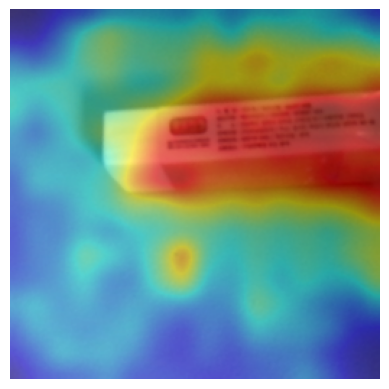

PATH :  ./시각화/eraser/


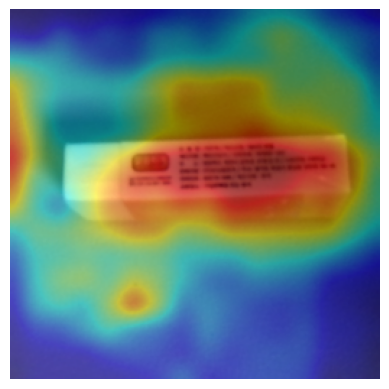

PATH :  ./시각화/eraser/


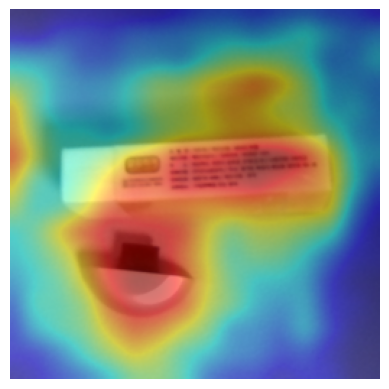

PATH :  ./시각화/eraser/


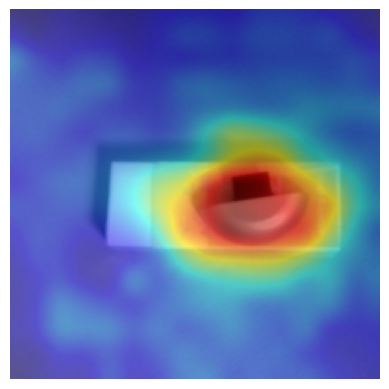

PATH :  ./시각화/eraser/


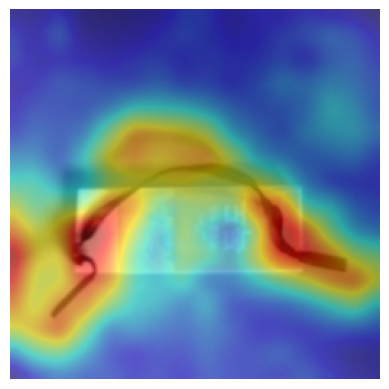

PATH :  ./시각화/eraser/


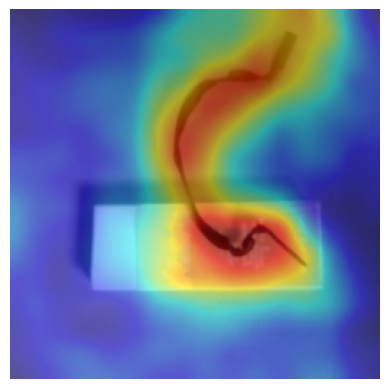

PATH :  ./시각화/eraser/


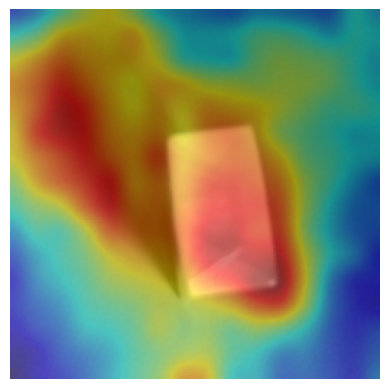

PATH :  ./시각화/eraser/


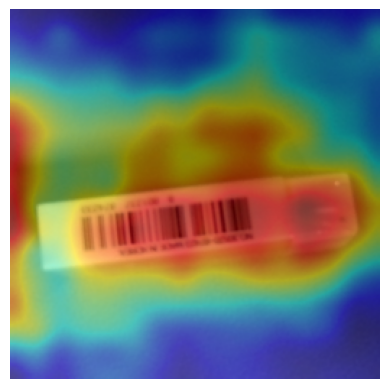

PATH :  ./시각화/eraser/


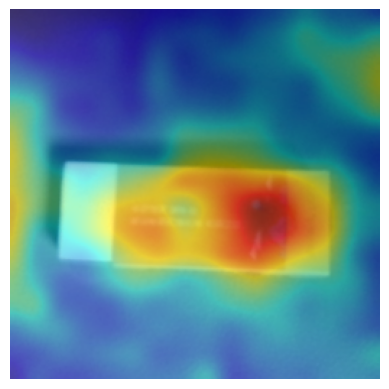

PATH :  ./시각화/eraser/


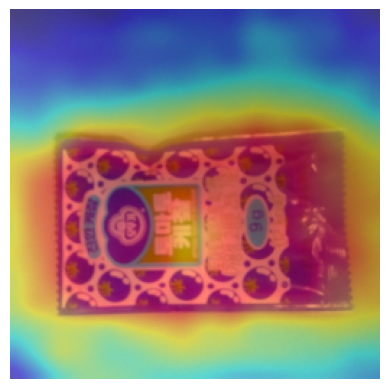

PATH :  ./시각화/eraser/


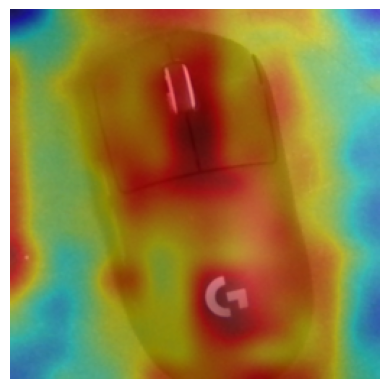

In [15]:
visualization('eraser', './시각화/eraser/')

# 가장 좋은 Threshold찾기
acc_max : Accuracy의 최댓값 <br>
acc_max_index : Accuracy가 최대일때의 이미지 주소(index) <br>
acc_max_len : Accuracy가 최대일때 주소의 길이 <br>
acc_max_threshold : Accuracy가 max인 threshold 범위 <br>
<br>
acc : Accuracy <br>
prc : Precision <br>
rcl : Recall <br>
f1 : F1-Score <br>
false : Fall_out <br>

In [16]:
best_threshold('eraser')

eraser
cuda
base_table was made
acc max 0.9545454545454546
acc_max_index (1, 128)
acc_max_len 128
acc_max_threshold 0.383 ~ 0.518

prc max 1.0
prc_max_index (1, 522)
prc_max_len 522
prc_max_threshold 0.479 ~ 1.0

rcl max 1.0
rcl_max_index (1, 470)
rcl_max_len 470
rcl_max_threshold 0.001 ~ 0.47

f1 max 0.9565217391304348
f1_max_index (1, 88)
f1_max_len 88
f1_max_threshold 0.383 ~ 0.47

false_min 1.0
false_min_index (1, 128)
false_min_len 128
false_min_threshold 0.383 ~ 0.518
◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆
◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆◆


# clasification_with_threshold
특정 Threshold일때 성능 평가

In [17]:
classification_with_threshold('eraser', 0.3)

eraser
cuda
threshold :  0.3
TP :  11
FN :  0
FP :  4
TN :  7
Accuracy :  0.8181818181818182
Precision :  0.7333333333333333
Recall :  1.0
Fall_out : 0.36363636363636365
